# MTM1 ODE model — instantaneous PI(3)P-dependent VPS34 feedback

Keep `ode_parameters_VPS34.yaml` and this notebook in the same folder. If PyYAML is missing, run `%pip install pyyaml` in a notebook cell once. Edit the YAML, then **Restart Kernel and Run All** to apply changes.

VPS34 remains implicit: there is no explicit VPS34 concentration. PI -> PI(3)P conversion is pseudo-first-order in free PI, while the effective rate is regulated instantaneously by PI(3)P-dependent negative feedback through an inhibitory Hill function:

- `VPS34_activity = basal_fraction + (1 - basal_fraction) / (1 + (PI3P / K_feedback)^hill_n)`
- `v_VPS34 = k_max * VPS34_activity * PI_free`

Thus high PI(3)P immediately lowers effective Rab5/VPS34 activity, whereas PI(3)P loss immediately relieves inhibition. There is no separate dynamic Rab5/VPS34 state and no relaxation/time-delay equation in this version. Time-delay was implemented in a previous version. It gave no decernable effect in the 0-120 seconds range, so was removed. The opposing MTM1 and VPS34 fluxes conserve the PI + PI(3)P lipid pool.

## Dynamic-cargo scenarios

The single dynamic-cargo assay pre-equilibrates at `dynamic_cargo_assay.start_fraction`, then allows total cargo to decay exponentially over one assay interval. The final repeated-cargo cell runs **3 consecutive assay intervals**. Cargo is reset to the configured starting fraction at the start of each interval and then undergoes the same exponential decay, while all other states carry continuously between intervals.


In [1]:
import sys
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd
import csv

# S = Snx17
# M = MTM1
# P = ProbeN
# A = Pi3P
# B = Pi
# C = Cargo


In [2]:
from pathlib import Path
import yaml

CONFIG_PATH = Path("ode_parameters_VPS34.yaml").resolve()
with CONFIG_PATH.open(encoding="utf-8") as f:
    config = yaml.safe_load(f)

affinities = config["affinities"]
Volume = config["geometry"]["Volume"]
TotalMembraneSA = config["geometry"]["TotalMembraneSA"]

# MTM1 catalysis.
keff_M = config["catalysis"]["keff_M"]
keff_SM = config["catalysis"]["keff_SM"]
if keff_SM is None:
    keff_SM = keff_M

# Implicit VPS34 / Rab5 negative-feedback parameters.
vps34 = config["vps34_feedback"]
k_VPS34_max = vps34["k_max"]
vps34_basal_fraction = vps34["basal_fraction"]
K_feedback = vps34["K_feedback"]
hill_n = vps34["hill_n"]

if not 0.0 <= vps34_basal_fraction <= 1.0:
    raise ValueError("vps34_feedback.basal_fraction must be between 0 and 1")
if K_feedback <= 0:
    raise ValueError("vps34_feedback.K_feedback must be > 0")
if hill_n <= 0:
    raise ValueError("vps34_feedback.hill_n must be > 0")
if k_VPS34_max < 0:
    raise ValueError("vps34_feedback.k_max must be >= 0")

params = dict(config["association_rates"])
ref = config["dissociation_reference"]
for suffix, kd_name in [("SA", "Kd_SA"), ("MA", "Kd_MA"),
                        ("PA", "Kd_PA"), ("PB", "Kd_PB")]:
    reference_koff = ref["probe_A_koff"] if suffix == "PA" else ref["bulk_koff"]
    params["koff_" + suffix] = reference_koff * (affinities[kd_name] / ref["bulk_Kd"])
for suffix, kd_name in [("SM", "Kd_SM"), ("SC", "Kd_SC")]:
    params["koff_" + suffix] = ref["surface_koff"] * (affinities[kd_name] / ref["surface_Kd"])

divisors = config["complex_off_rate_divisors"]
params["koff_SAM"] = params["koff_SA"] / divisors["SAM"]
params["koff_SAC"] = params["koff_SA"] / divisors["SAC"]
params.update(
    keff_M=keff_M,
    keff_SM=keff_SM,
    k_VPS34_max=k_VPS34_max,
    vps34_basal_fraction=vps34_basal_fraction,
    K_feedback=K_feedback,
    hill_n=hill_n,
    ka=config["transport"]["ka"],
)

eq_Snx17_conc = config["equilibration"]["Snx17_conc"]
eq_MTM1_conc = config["equilibration"]["MTM1_conc"]
eq_Probe_conc = config["equilibration"]["Probe_conc"]
eq_cargo_conc = config["equilibration"]["cargo_fraction"]
PC_concentration = config["membrane"]["PC_concentration"]
membrane_substrate = config["membrane"]["membrane_substrate"]
membrane_product = config["membrane"]["membrane_product"]
equilibration_time = config["equilibration"]["time_s"]
initial_Snx17_conc = config["assay"]["Snx17_conc"]
initial_MTM1_conc = config["assay"]["MTM1_conc"]
initial_Probe_conc = config["assay"]["Probe_conc"]
simulation_time = config["assay"]["time_s"]
solver_options = dict(config["solver"])
file_settings = config["files"]
results_csv = CONFIG_PATH.parent / file_settings["results_csv"]


In [3]:
# Starting PI(3)P concentration.
initial_A = PC_concentration * membrane_substrate

# State order (15 states):
# Sa, Ma, Pa, Sf, Mf, Pf, SbA, MbA, PbA, PbB, SMb, SbC, A, B, C
equilibration_concentrations = [
    0, # Sa
    0, # Ma
    0, # Pa
    eq_Snx17_conc, # Sf
    eq_MTM1_conc, # Mf
    eq_Probe_conc, # Pf
    0, # SbA
    0, # MbA
    0, # PbA
    0, # PbB
    0, # SMb
    0, # SbC
    initial_A, # A = PI(3)P
    PC_concentration * membrane_product, # B = PI
    PC_concentration * eq_cargo_conc, # C
]

# ===================== ODE Model =====================

def change_in_bidning(kon, substrate,
                      koff, free_form, bound_form):
    return kon * substrate * free_form - koff * bound_form


def model(t, y):
    global params
    Sa, Ma, Pa, Sf, Mf, Pf, SbA, MbA, PbA, PbB, SMb, SbC, A, B, C = y

    kon_SA   = params["kon_SA"]
    koff_SA  = params["koff_SA"]
    kon_MA   = params["kon_MA"]
    koff_MA  = params["koff_MA"]
    kon_PA   = params["kon_PA"]
    koff_PA  = params["koff_PA"]
    kon_PB   = params["kon_PB"]
    koff_PB  = params["koff_PB"]
    kon_SM   = params["kon_SM"]
    koff_SM  = params["koff_SM"]
    koff_SAM = params["koff_SAM"]
    kon_SC   = params["kon_SC"]
    koff_SC  = params["koff_SC"]
    koff_SAC = params["koff_SAC"]
    keff_M   = params["keff_M"]
    keff_SM  = params["keff_SM"]
    k_VPS34_max = params["k_VPS34_max"]
    basal_fraction = params["vps34_basal_fraction"]
    K_feedback = params["K_feedback"]
    hill_n = params["hill_n"]
    ka = params["ka"]

    # Free lipid/cargo available for binding.
    A_bind = max((A - SbA - MbA - PbA - (SMb * 2) - SbC), 0.0)
    B_bind = max((B - PbB), 0.0)
    C_bind = max((C - SbC), 0.0)

    # Instantaneous PI(3)P-dependent negative feedback onto VPS34.
    A_feedback = max(A, 0.0)
    Rab5_activity_for_flux = basal_fraction + (
        (1.0 - basal_fraction) /
        (1.0 + (A_feedback / K_feedback) ** hill_n)
    )
    Rab5_activity_for_flux = np.clip(Rab5_activity_for_flux, 0.0, 1.0)

    # Convert nM to molecules/um2 for 2D binding calculations.
    aMbA = ((MbA * 0.602) * Volume) / TotalMembraneSA
    aSbA = ((SbA * 0.602) * Volume) / TotalMembraneSA
    aSMb = ((SMb * 0.602) * Volume) / TotalMembraneSA
    aC_bind = ((C_bind * 0.602) * Volume) / TotalMembraneSA
    aSbC = ((SbC * 0.602) * Volume) / TotalMembraneSA

    # 2D reaction rates (molecules/um2/s).
    SMb_rate_mum2 = change_in_bidning(kon_SM, aMbA, koff_SM, aSbA, aSMb)
    SbC_rate_mum2 = change_in_bidning(kon_SC, aC_bind, koff_SC, aSbA, aSbC)

    # Convert 2D rates back to nM/s.
    SMb_rate_nM = (SMb_rate_mum2 * TotalMembraneSA) / (0.602 * Volume)
    SbC_rate_nM = (SbC_rate_mum2 * TotalMembraneSA) / (0.602 * Volume)

    # Diffusion from compartment 1 -> compartment 2.
    dSa = -(ka * Sa)
    dMa = -(ka * Ma)
    dPa = -(ka * Pa)

    # Free S, M, and P.
    dSf = -change_in_bidning(kon_SA, A_bind, koff_SA, Sf, SbA) + \
          (koff_SAC * SbC) + \
          (koff_SAM * SMb) + (ka * Sa)

    dMf = -change_in_bidning(kon_MA, A_bind, koff_MA, Mf, MbA) + \
          (koff_SAM * SMb) + (ka * Ma)

    dPf = -change_in_bidning(kon_PA, A_bind, koff_PA, Pf, PbA) + \
          -change_in_bidning(kon_PB, B_bind, koff_PB, Pf, PbB) + (ka * Pa)

    # Binding from compartment 2 -> compartment 3.
    dSbA = change_in_bidning(kon_SA, A_bind, koff_SA, Sf, SbA) - \
          SMb_rate_nM - SbC_rate_nM

    dMbA = change_in_bidning(kon_MA, A_bind, koff_MA, Mf, MbA) - \
          SMb_rate_nM

    dPbA = change_in_bidning(kon_PA, A_bind, koff_PA, Pf, PbA)
    dPbB = change_in_bidning(kon_PB, B_bind, koff_PB, Pf, PbB)

    # Snx17-MTM1 and Snx17-cargo membrane complexes.
    dSMb = SMb_rate_nM - (koff_SAM * SMb)
    dSbC = SbC_rate_nM - (koff_SAC * SbC)

    # Catalysis / lipid interconversion.
    # MTM1: PI(3)P -> PI.
    v_MTM1 = (keff_M * MbA * A_bind) + \
             (keff_SM * SMb * A_bind)

    # VPS34: PI -> PI(3)P.
    v_VPS34 = k_VPS34_max * Rab5_activity_for_flux * B_bind

    # Opposing fluxes conserve A + B (PI(3)P + PI).
    dA = v_VPS34 - v_MTM1
    dB = v_MTM1 - v_VPS34

    return [dSa, dMa, dPa, dSf, dMf, dPf, dSbA, dMbA, dPbA, dPbB,
            dSMb, dSbC, dA, dB, 0]


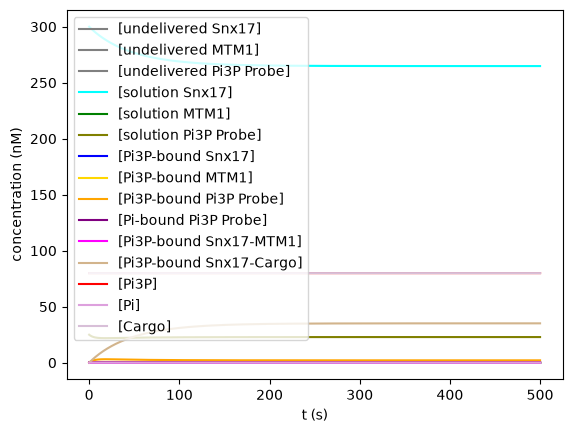

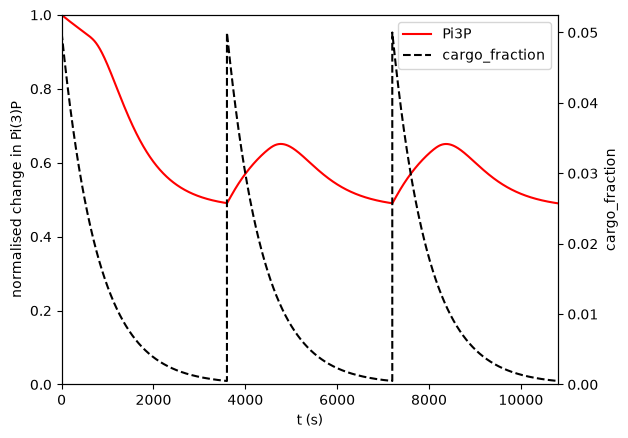

Repeated dynamic-cargo assay: 3 cycles x 3600 s = 10800 s total
Within each cycle cargo_fraction decays from 0.050000 to 0.000500; k_decay = 0.00127921 s^-1


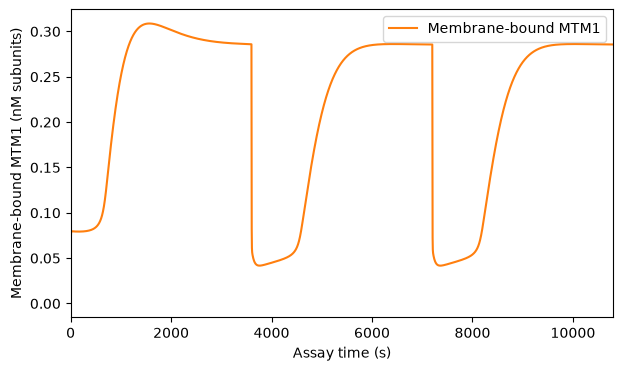

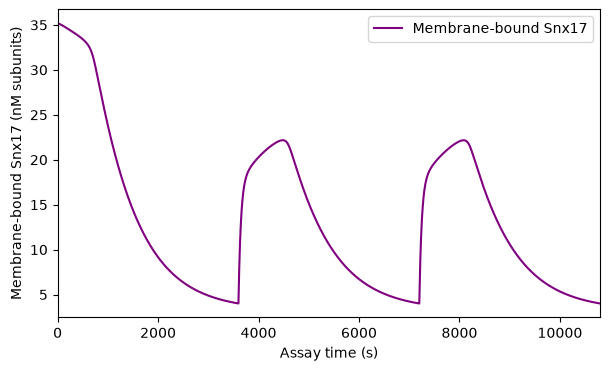

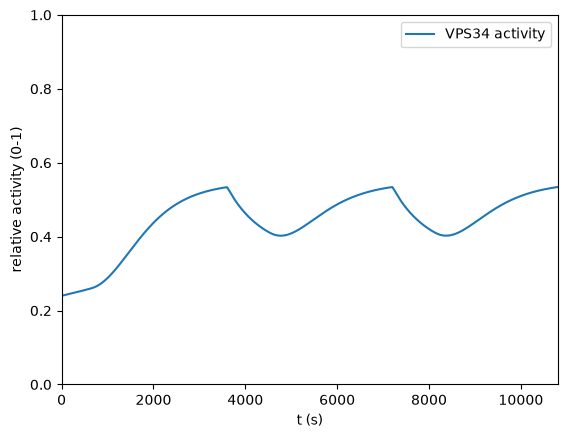

Repeated dynamic-cargo results written to: C:\Users\lewis\Downloads\Jupyter_moldels\GitHub_ready\ODE_repeating_cargo_delivery\results_dynamic_cargo_3x_resets.csv


In [4]:
# ===================== Repeated dynamic cargo assay: 3 cycles =====================
# This scenario runs for 3x the normal assay duration.
# At the start of each 1x assay interval, total cargo is set to the YAML
# start_fraction and then decays exponentially over that interval.
# All other model states carry continuously from one interval to the next.

from types import SimpleNamespace

repeat_cycles = 3

dynamic_cargo_repeat = config["dynamic_cargo_assay"]
cargo_fraction_start_repeat = float(dynamic_cargo_repeat["start_fraction"])
cargo_fraction_final_relative_repeat = float(dynamic_cargo_repeat["final_fraction_of_start"])

if cargo_fraction_start_repeat < 0:
    raise ValueError("dynamic_cargo_assay.start_fraction must be >= 0")
if not 0 < cargo_fraction_final_relative_repeat <= 1:
    raise ValueError("dynamic_cargo_assay.final_fraction_of_start must be > 0 and <= 1")

base_assay_start = float(simulation_time[0])
base_assay_end = float(simulation_time[1])
base_assay_duration = base_assay_end - base_assay_start
if base_assay_duration <= 0:
    raise ValueError("assay.time_s must have a positive duration")

k_cargo_decay_repeat = -np.log(cargo_fraction_final_relative_repeat) / base_assay_duration
cargo_fraction_target_end_repeat = (
    cargo_fraction_start_repeat * cargo_fraction_final_relative_repeat
)

repeated_simulation_time = [
    base_assay_start,
    base_assay_start + repeat_cycles * base_assay_duration,
]

def model_dynamic_cargo_repeat(t, y):
    dydt = list(model(t, y))
    dydt[14] = -k_cargo_decay_repeat * max(y[14], 0.0)
    return dydt

repeat_label_list = ["[undelivered Snx17]", "[undelivered MTM1]", "[undelivered Pi3P Probe]", "[solution Snx17]", "[solution MTM1]", "[solution Pi3P Probe]",
                     "[Pi3P-bound Snx17]", "[Pi3P-bound MTM1]", "[Pi3P-bound Pi3P Probe]", "[Pi-bound Pi3P Probe]", "[Pi3P-bound Snx17-MTM1]",
                     "[Pi3P-bound Snx17-Cargo]", "[Pi3P]", "[Pi]", "[Cargo]"]
repeat_colour_list = ["grey", "grey", "grey", "cyan", "green", "olive", "blue", "gold",
                      "orange", "purple", "fuchsia", "tan", "red", "plum", "thistle"]

# --------------------- Pre-equilibration ---------------------
repeat_equilibration_concentrations = list(equilibration_concentrations)
repeat_equilibration_concentrations[14] = PC_concentration * cargo_fraction_start_repeat

repeat_eq_sol = solve_ivp(
    fun=model,
    t_span=equilibration_time,
    y0=repeat_equilibration_concentrations,
    **solver_options,
)
repeat_y_EQ = repeat_eq_sol.y[:, -1]

plt.figure()
for i in range(len(repeat_label_list)):
    plt.plot(repeat_eq_sol.t, repeat_eq_sol.y[i], label=repeat_label_list[i], c=repeat_colour_list[i])
plt.xlabel('t (s)')
plt.ylabel('concentration (nM)')
plt.legend()
plt.show()

# --------------------- Assay initialisation ---------------------
repeat_assay_concentrations = [
    0, # Sa
    0, # Ma
    0, # Pa
    initial_Snx17_conc, # Sf
    initial_MTM1_conc, # Mf
    initial_Probe_conc, # Pf
    0, # SbA
    0, # MbA
    0, # PbA
    0, # PbB
    0, # SMb
    0, # SbC
    PC_concentration * membrane_substrate, # A
    PC_concentration * membrane_product, # B
    PC_concentration * cargo_fraction_start_repeat, # C
]

for component_no, value in enumerate(repeat_y_EQ):
    if value > 0.0:
        repeat_assay_concentrations[component_no] = value

repeat_assay_concentrations[14] = PC_concentration * cargo_fraction_start_repeat

# --------------------- Three consecutive assay intervals ---------------------
segment_times = []
segment_states = []
segment_cycle_ids = []
current_state = np.asarray(repeat_assay_concentrations, dtype=float)

for cycle in range(repeat_cycles):
    cycle_start = base_assay_start + cycle * base_assay_duration
    cycle_end = cycle_start + base_assay_duration

    if cycle > 0:
        current_state = current_state.copy()
        current_state[14] = PC_concentration * cargo_fraction_start_repeat

    cycle_sol = solve_ivp(
        fun=model_dynamic_cargo_repeat,
        t_span=(cycle_start, cycle_end),
        y0=current_state,
        **solver_options,
    )

    segment_times.append(cycle_sol.t)
    segment_states.append(cycle_sol.y)
    segment_cycle_ids.append(np.full(cycle_sol.t.shape, cycle + 1, dtype=int))
    current_state = cycle_sol.y[:, -1].copy()

repeat_t = np.concatenate(segment_times)
repeat_y = np.concatenate(segment_states, axis=1)
repeat_cycle_id = np.concatenate(segment_cycle_ids)
repeat_sol = SimpleNamespace(t=repeat_t, y=repeat_y)

# --------------------- Normalised PI(3)P plot ---------------------
repeat_max_A = max(repeat_sol.y[12])
repeat_normalised_A = [(n / repeat_max_A) for n in repeat_sol.y[12]]

repeat_max_PbA = max(repeat_sol.y[8])
if repeat_max_PbA > 0:
    repeat_normalised_PbA = [(n / repeat_max_PbA) for n in repeat_sol.y[8]]
else:
    repeat_normalised_PbA = np.zeros_like(repeat_sol.t)

repeat_cargo_fraction_trace = repeat_sol.y[14] / PC_concentration

fig, ax1 = plt.subplots()
pi3p_line_repeat, = ax1.plot(
    repeat_sol.t,
    repeat_normalised_A,
    label="Pi3P",
    c=repeat_colour_list[12],
)
ax1.set_ylim(0, 1)
ax1.set_xlim(*repeated_simulation_time)
ax1.set_xlabel('t (s)')
ax1.set_ylabel('normalised change in Pi(3)P')

ax2 = ax1.twinx()
cargo_line_repeat, = ax2.plot(
    repeat_sol.t,
    repeat_cargo_fraction_trace,
    label="cargo_fraction",
    c="black",
    linestyle="--",
)
ax2.set_ylabel('cargo_fraction')
ax2.set_ylim(0, cargo_fraction_start_repeat * 1.05)

lines_repeat = [pi3p_line_repeat, cargo_line_repeat]
ax1.legend(lines_repeat, [line.get_label() for line in lines_repeat])
plt.show()

print(
    f"Repeated dynamic-cargo assay: {repeat_cycles} cycles x {base_assay_duration:g} s "
    f"= {repeat_cycles * base_assay_duration:g} s total"
)
print(
    f"Within each cycle cargo_fraction decays from {cargo_fraction_start_repeat:.6f} "
    f"to {cargo_fraction_target_end_repeat:.6f}; "
    f"k_decay = {k_cargo_decay_repeat:.6g} s^-1"
)

# --------------------- Membrane-bound MTM1 plot ---------------------
repeat_bound_mtm1 = repeat_sol.y[7] + repeat_sol.y[10]

plt.figure(figsize=(7, 4))
plt.plot(
    repeat_sol.t,
    repeat_bound_mtm1,
    label="Membrane-bound MTM1",
    color="tab:orange",
)
plt.xlim(*repeated_simulation_time)
plt.xlabel('Assay time (s)')
plt.ylabel('Membrane-bound MTM1 (nM subunits)')
plt.legend()
plt.show()

# --------------------- Membrane-bound Snx17 plot ---------------------
repeat_bound_snx17 = repeat_sol.y[6] + repeat_sol.y[10] + repeat_sol.y[11]

plt.figure(figsize=(7, 4))
plt.plot(
    repeat_sol.t,
    repeat_bound_snx17,
    label="Membrane-bound Snx17",
    c=repeat_colour_list[9],
)
plt.xlim(*repeated_simulation_time)
plt.xlabel('Assay time (s)')
plt.ylabel('Membrane-bound Snx17 (nM subunits)')
plt.legend()
plt.show()

# --------------------- Instantaneous VPS34 feedback diagnostic ---------------------
repeat_A_feedback = np.maximum(repeat_sol.y[12], 0.0)
repeat_vps34_activity = vps34_basal_fraction + (
    (1.0 - vps34_basal_fraction) /
    (1.0 + (repeat_A_feedback / K_feedback) ** hill_n)
)
repeat_vps34_activity = np.clip(repeat_vps34_activity, 0.0, 1.0)
repeat_k_VPS34_effective = k_VPS34_max * repeat_vps34_activity

plt.figure()
plt.plot(repeat_sol.t, repeat_vps34_activity, label="VPS34 activity")
plt.ylim(0, 1)
plt.xlim(*repeated_simulation_time)
plt.xlabel('t (s)')
plt.ylabel('relative activity (0-1)')
plt.legend()
plt.show()

# --------------------- CSV outputs ---------------------
repeat_results_csv = results_csv.with_name(
    results_csv.stem + "_dynamic_cargo_3x_resets" + results_csv.suffix
)

# Save once per second; this does not alter the solver's internal time steps.
save_times = np.arange(
    np.ceil(repeat_sol.t[0]),
    np.floor(repeat_sol.t[-1]) + 1,
    1.0,
)

save_Pi3P_norm = np.interp(save_times, repeat_sol.t, repeat_normalised_A)
save_2xPX_norm = np.interp(save_times, repeat_sol.t, repeat_normalised_PbA)
save_cargo_fraction = np.interp(save_times, repeat_sol.t, repeat_cargo_fraction_trace)
save_cargo_total = np.interp(save_times, repeat_sol.t, repeat_sol.y[14])
save_bound_mtm1 = np.interp(save_times, repeat_sol.t, repeat_bound_mtm1)
save_bound_snx17 = np.interp(save_times, repeat_sol.t, repeat_bound_snx17)
save_k_VPS34 = np.interp(save_times, repeat_sol.t, repeat_k_VPS34_effective)

save_cycle_id = np.minimum(
    ((save_times - base_assay_start) // base_assay_duration).astype(int) + 1,
    repeat_cycles,
)

with repeat_results_csv.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "time (s)",
        "cycle",
        "Pi3P_norm",
        "2xPX_norm",
        "cargo_fraction",
        "cargo_total_nM",
        "membrane_bound_MTM1_nM_subunits",
        "membrane_bound_Snx17_nM_subunits",
        "k_VPS34_effective_s^-1",
    ])
    writer.writerows(zip(
        save_times,
        save_cycle_id,
        save_Pi3P_norm,
        save_2xPX_norm,
        save_cargo_fraction,
        save_cargo_total,
        save_bound_mtm1,
        save_bound_snx17,
        save_k_VPS34,
    ))

print(f"Repeated dynamic-cargo results written to: {repeat_results_csv}")
